____

# Advanced Retrieval-Augmented Generation (RAG) and Language Model Implementation

## Educational Implementation and Analysis

<h2>IMPORTANT DISCLAIMER</h2>

This notebook is developed for personal learning and educational purposes only.
It is not intended for commercial use or distribution. The implementation combines
multiple AI techniques and serves as a comprehensive study of modern RAG and agentic systems,
inspired by 2025 advancements in multi-agent coordination, dynamic planning, and LLM-driven creativity.

The document corpus used consists of publicly available NASA educational materials,
used here for demonstration and learning purposes in accordance with fair use principles.

In [3]:
# =============================================================================
# SECTION 1: DEPENDENCIES AND SYSTEM INITIALIZATION
# =============================================================================

# Installation requirements (run this cell first if packages are not installed)
# pip install torch transformers sentence-transformers faiss-cpu langchain langchain-community pypdf2 rank-bm25 numpy networkx matplotlib

import torch
import numpy as np
import faiss
import re
import json
from typing import Dict, List, Any, Optional
from dataclasses import dataclass
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from rank_bm25 import BM25Okapi
import warnings
import networkx as nx
import matplotlib.pyplot as plt
from io import StringIO

warnings.filterwarnings("ignore")

print("All dependencies loaded successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All dependencies loaded successfully
PyTorch version: 2.8.0+cu128
CUDA available: True


In [4]:
# =============================================================================
# SECTION 2: MODEL CONFIGURATION AND SELECTION
# =============================================================================

# Model configuration
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"


def initialize_system():
    print("Initializing AI system components...")

    # Initialize tokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

    # Initialize language model with memory optimization
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        dtype=torch.float16,  # Use float16 for memory efficiency
        device_map="cuda" if torch.cuda.is_available() else "cpu",
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )

    # Initialize embedding model for semantic search
    embedder = SentenceTransformer("all-MiniLM-L6-v2")

    return tokenizer, model, embedder


# Initialize system components
tokenizer, model, embedder = initialize_system()
print(f"System initialized successfully with {MODEL_NAME}")

Initializing AI system components...
System initialized successfully with Qwen/Qwen2.5-0.5B-Instruct


In [5]:
# =============================================================================
# SECTION 3: TEXT GENERATION ENGINE
# =============================================================================


def generate_response(prompt, max_tokens=350, temperature=0.1):
    try:
        # Format prompt for instruction-following model
        messages = [{"role": "user", "content": prompt}]
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        # Tokenize input with proper truncation
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        # Generate response with memory efficiency
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_tokens,
                temperature=temperature,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        # Decode and return clean response
        response = tokenizer.decode(
            outputs[0][len(inputs["input_ids"][0]) :], skip_special_tokens=True
        )
        return response.strip()

    except Exception as e:
        return f"Generation error: {str(e)}"


# Test the text generation system
test_response = generate_response(
    "Explain the concept of artificial intelligence in simple terms."
)
print("Text Generation Test:")
print(f"Response: {test_response}")

Text Generation Test:
Response: Artificial Intelligence (AI) is a field that focuses on creating machines and software that can perform tasks that typically require human intelligence, such as learning, reasoning, problem-solving, perception, and natural language processing. In simpler terms, AI involves designing computer systems that can think like humans and make decisions based on data.

Here's how it works:

1. **Data Collection**: The first step is to gather large amounts of data from various sources, including databases, sensors, and other digital devices.

2. **Data Processing**: This involves analyzing the collected data using algorithms and machine learning techniques to extract insights and patterns.

3. **Model Development**: Based on the analysis, models are developed that can understand and predict outcomes based on the data.

4. **Decision Making**: These models then use this information to make predictions or take actions that are beneficial for the system or its users.

In [6]:
# =============================================================================
# SECTION 4: DOCUMENT PROCESSING PIPELINE
# =============================================================================


def process_documents(docs_path="./documents"):
    print(f"Processing documents from: {docs_path}")

    # Step 1: Load documents
    documents = []
    docs_directory = Path(docs_path)

    if not docs_directory.exists():
        print(
            f"Warning: Directory {docs_path} not found. Creating example documents..."
        )
        docs_directory.mkdir(exist_ok=True)

        # Create sample NASA-style educational content
        sample_content = """
        NASA's Mission to Mars: Understanding Rocket Propulsion
        
        Rocket propulsion operates on Newton's third law of motion: for every action, 
        there is an equal and opposite reaction. When propellant is expelled from a 
        rocket engine at high velocity, it creates thrust that propels the spacecraft forward.
        
        The basic rocket equation, developed by Konstantin Tsiolkovsky, describes the
        relationship between rocket mass, exhaust velocity, and achievable velocity:
        Δv = ve * ln(m0/mf)
        
        Where:
        - Δv is the change in velocity
        - ve is the effective exhaust velocity
        - m0 is the initial mass
        - mf is the final mass
        
        This fundamental equation governs all rocket design and mission planning for
        interplanetary travel.
        """

        with open(docs_directory / "sample_nasa_content.txt", "w") as f:
            f.write(sample_content)

    # Load PDF documents
    for pdf_file in docs_directory.glob("*.pdf"):
        try:
            loader = PyPDFLoader(str(pdf_file))
            pages = loader.load()
            for page in pages:
                page.metadata.update({"source": pdf_file.name})
                documents.append(page)
            print(f"Loaded: {pdf_file.name}")
        except Exception as e:
            print(f"Error loading {pdf_file}: {e}")

    # Load text documents
    for txt_file in docs_directory.glob("*.txt"):
        try:
            with open(txt_file, "r", encoding="utf-8") as f:
                content = f.read()
                # Create document-like object
                doc_obj = type(
                    "Document",
                    (),
                    {"page_content": content, "metadata": {"source": txt_file.name}},
                )()
                documents.append(doc_obj)
            print(f"Loaded: {txt_file.name}")
        except Exception as e:
            print(f"Error loading {txt_file}: {e}")

    if not documents:
        raise ValueError(
            "No documents found. Please add PDF or TXT files to the documents directory."
        )

    # Step 2: Split documents into chunks
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=750,  # Optimal size for context preservation
        chunk_overlap=150,  # Overlap to prevent information loss
        separators=["\n\n", "\n", ". ", " "],  # Hierarchical splitting
        keep_separator=True,
    )
    chunks = splitter.split_documents(documents)
    texts = [chunk.page_content for chunk in chunks]

    # Step 3: Generate embeddings for semantic search
    print("Generating embeddings for semantic search...")
    embeddings = embedder.encode(texts, batch_size=16, show_progress_bar=False)

    # Step 4: Create FAISS index for efficient similarity search
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)  # Inner product for cosine similarity
    faiss.normalize_L2(embeddings.astype("float32"))
    index.add(embeddings.astype("float32"))

    # Step 5: Create BM25 index for keyword search
    tokenized_texts = [re.findall(r"\w+", text.lower()) for text in texts]
    bm25 = BM25Okapi(tokenized_texts)

    print(f"Document processing complete:")
    print(f"- Total chunks: {len(texts)}")
    print(f"- Embedding dimension: {dim}")
    print(
        f"- Average chunk length: {np.mean([len(text) for text in texts]):.0f} characters"
    )

    return {
        "texts": texts,
        "chunks": chunks,
        "embeddings": embeddings,
        "faiss_index": index,
        "bm25_index": bm25,
        "tokenized_texts": tokenized_texts,
    }


# Process documents and create knowledge base
doc_system = process_documents()

Processing documents from: ./documents
Loaded: main_ShuttleRetrospective.pdf
Loaded: NASA_exploration.pdf
Loaded: rockets-educator-guide-20.pdf
Generating embeddings for semantic search...
Document processing complete:
- Total chunks: 1051
- Embedding dimension: 384
- Average chunk length: 574 characters


In [7]:
# =============================================================================
# SECTION 5: UNIVERSAL SEARCH SYSTEM
# =============================================================================


def universal_search(query, method="hybrid", k=5, threshold=0.6, alpha=0.7):
    semantic_results = []
    keyword_results = []

    # Semantic Search
    if method in ["semantic", "hybrid"]:
        query_vector = embedder.encode([query])
        faiss.normalize_L2(query_vector.astype("float32"))
        similarities, indices = doc_system["faiss_index"].search(
            query_vector.astype("float32"), k=k * 2
        )
        for sim, idx in zip(similarities[0], indices[0]):
            if sim > threshold:
                semantic_results.append({"index": int(idx), "score": float(sim)})

    # Keyword Search
    if method in ["keyword", "hybrid"]:
        query_tokens = re.findall(r"\w+", query.lower())
        bm25_scores = doc_system["bm25_index"].get_scores(query_tokens)
        top_indices = np.argsort(bm25_scores)[::-1][: k * 2]
        max_score = max(bm25_scores) if max(bm25_scores) > 0 else 1
        for idx in top_indices:
            if bm25_scores[idx] > 0:
                normalized_score = bm25_scores[idx] / max_score
                if normalized_score > threshold:
                    keyword_results.append(
                        {"index": int(idx), "score": float(normalized_score)}
                    )

    # Weighted Hybrid Fusion using Reciprocal Rank Fusion (RRF)
    if method == "hybrid" and semantic_results and keyword_results:
        scores = {}
        for res in semantic_results + keyword_results:
            idx = res["index"]
            if idx not in scores:
                scores[idx] = 0
            rank_sem = next(
                (i + 1 for i, r in enumerate(semantic_results) if r["index"] == idx),
                len(semantic_results) + 1,
            )
            rank_key = next(
                (i + 1 for i, r in enumerate(keyword_results) if r["index"] == idx),
                len(keyword_results) + 1,
            )
            rrf_score = (1 / (rank_sem + 60)) + (1 / (rank_key + 60))
            scores[idx] = alpha * rrf_score

        fused = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
        results = [
            {
                "text": doc_system["texts"][idx],
                "score": score,
                "method": "hybrid",
                "index": idx,
            }
            for idx, score in fused
        ]
    else:
        results = semantic_results[:k] if method == "semantic" else keyword_results[:k]
        results = [
            {
                "text": doc_system["texts"][r["index"]],
                "score": r["score"],
                "method": method,
                "index": r["index"],
            }
            for r in results
        ]

    return results


# Test search
questions_search = [
    "rocket propulsion physics",
    "STS-44",
    "Do there exist many worlds ...",
    "Man hath weaved out a net, and this net throwne ....",
    "Roger Bacon",
    "Project X - 51",
]

for question in questions_search:
    search_results = universal_search(question, method="hybrid", k=10)
    print("\n\n" + "-" * 75)
    print(f"Search Test - Query: '{question}'")
    print(f"Found {len(search_results)} results:")
    for i, result in enumerate(search_results, 1):
        print(f"\n{i}. Score: {result['score']:.3f} | Method: {result['method']}")
        print(f"   Text: {result['text']}")



---------------------------------------------------------------------------
Search Test - Query: 'rocket propulsion physics'
Found 10 results:

1. Score: 0.023 | Method: hybrid
   Text: the primary payload on this mission was Spacelab-2. Despite an abort-to-orbit (ato), which required mission replanning, 
the mission was declared a success. a special part of the modular Spacelab system, “the igloo,” located at the head of 
three-pallet train, provided onsite support to instruments mounted on pallets. the main mission objective was to verify 
the performance of Spacelab systems, determine interface capability of the orbiter, measure the environment induced by 
the spacecraft. experiments covered life sciences, plasma physics, astronomy, high-energy astrophysics, solar physics, 
atmospheric physics, and technology research.

2. Score: 0.022 | Method: hybrid
   Text: StS-9 carried the first Spacelab mission and the first european Space agency (eSa) astronaut, ulf D. merbold of germany. 

In [8]:
# =============================================================================
# SECTION 6: RETRIEVAL-AUGMENTED GENERATION (RAG) IMPLEMENTATIONS
# =============================================================================


# Simple RAG Implementation
def simple_rag(
    query,
    search_method="hybrid",
    max_chars_context=2000,
    max_output_tokens=350,
    k_docs_rag=5,
):
    results = universal_search(query, method=search_method, k=k_docs_rag)

    if results:
        context = "\n\n".join([r["text"] for r in results])[:max_chars_context]
        prompt = f"Based on this information:\n\n{context}\n\nAnswer: {query}"
    else:
        prompt = f"Answer with general knowledge: {query}"

    response = generate_response(prompt, max_tokens=max_output_tokens)
    return response, len(results)


# Self-RAG Implementation
def self_rag(query, max_output_tokens=350):
    check_prompt = f"Does this question require external documents to answer accurately? Question: {query}\nAnswer: YES or NO"
    needs_docs = generate_response(check_prompt, max_tokens=10)

    if "yes" in needs_docs.lower():
        response, num_docs = simple_rag(query)

        query_emb = embedder.encode([query])
        resp_emb = embedder.encode([response])
        confidence = np.dot(query_emb, resp_emb.T)[0][0] / (
            np.linalg.norm(query_emb) * np.linalg.norm(resp_emb)
        )

        if confidence < 0.7:
            refine_prompt = f"Improve this response to better address the question:\nOriginal: {response}\nQuestion: {query}\nImproved:"
            response = generate_response(refine_prompt, max_tokens=max_output_tokens)
    else:
        response = generate_response(f"Explain: {query}", max_tokens=max_output_tokens)

    return response


# HyDE RAG Implementation
def hyde_rag(
    query,
    max_char_context=1500,
    max_output_tokens=350,
    max_output_hyde_tokens=250,
    k_rag_documents=5,
    rag_min_score=0.5,
):
    hyp_prompt = f"Write a technical paragraph that answers: {query}"
    hypothetical_doc = generate_response(hyp_prompt, max_tokens=max_output_hyde_tokens)

    results = universal_search(
        hypothetical_doc, method="semantic", k=k_rag_documents, threshold=rag_min_score
    )

    if results:
        context = "\n\n".join([r["text"] for r in results])[:max_char_context]
        final_prompt = f"Real information found:\n{context}\n\nOriginal question: {query}\nAnswer based on real information:"
        response = generate_response(final_prompt, max_tokens=max_output_tokens)
    else:
        response = generate_response(f"Answer: {query}", max_tokens=max_output_tokens)

    return response


# Test RAG implementations
test_queries = [
    "How do rocket engines work in space?",
    "What is the rocket equation?",
    "Explain Newton's laws in rocket propulsion",
]

print("Testing RAG Implementations:")
print("=" * 50)

for i, query in enumerate(test_queries, 1):
    print(f"\nTest {i}: {query}")
    print("-" * 30)

    simple_response, doc_count = simple_rag(query)
    print(f"Simple RAG ({doc_count} docs): {simple_response}")

    self_response = self_rag(query)
    print(f"Self-RAG: {self_response}")

    hyde_response = hyde_rag(query)
    print(f"HyDE RAG: {hyde_response}")

Testing RAG Implementations:

Test 1: How do rocket engines work in space?
------------------------------
Simple RAG (5 docs): Rocket engines work in space by expelling gases at high speeds through a nozzle. These gases then collide with objects in orbit around Earth, such as satellites, spacecraft, or even small robotic devices. The expelled gases create thrust, which propels the object forward.

In terms of propulsion, rocket engines use chemical reactions to convert fuel into energy. When the fuel burns, it releases heat and light, which drives the combustion process. The exhaust gases from the engine are directed towards the nozzle where they are accelerated and directed towards the target object.

For example, when a rocket engine uses liquid hydrogen and liquid oxygen as its propellant, the reaction between these two gases produces a large amount of energy. As the gas expands and cools, it creates a powerful jet of hot gas that pushes against the rocket's exhaust system.

This me

In [9]:
# =============================================================================
# SECTION 7: DYNAMIC AGENT SYSTEM
# =============================================================================


@dataclass
class AgentMemory:
    observations: List[str] = None
    plan: List[Dict[str, str]] = None
    reflections: List[str] = None
    thoughts: List[str] = None

    def __post_init__(self):
        if self.observations is None:
            self.observations = []
        if self.plan is None:
            self.plan = []
        if self.reflections is None:
            self.reflections = []
        if self.thoughts is None:
            self.thoughts = []

    def add_observation(self, obs: str):
        self.observations.append(obs)

    def add_reflection(self, reflection: str):
        self.reflections.append(reflection)

    def add_thought(self, thought: str):
        self.thoughts.append(thought)

    def get_context(self, max_chars: int = 2000) -> str:
        summary = f"Thoughts: {'; '.join(self.thoughts[-2:])} | Observations: {'; '.join(self.observations[-3:])} | Reflections: {'; '.join(self.reflections[-2:])}"
        return summary[-max_chars:]


class Tool:
    name: str
    description: str

    def execute(self, params: Dict[str, Any]) -> str:
        raise NotImplementedError("Subclasses must implement execute.")


class SearchTool(Tool):
    def __init__(self):
        self.name = "search_documents"
        self.description = "Search the knowledge base for relevant information. Params: {'query': str, 'k': int=5}"

    def execute(self, params: Dict[str, Any]) -> str:
        query = params.get("query", "")
        k = params.get("k", 5)
        results = universal_search(query, method="hybrid", k=k)
        if results:
            texts = [r["text"] for r in results[:3]]
            return f"Retrieved {len(results)} docs: {' | '.join(texts)}"
        return "No relevant documents found."


class AnalyzeTool(Tool):
    def __init__(self):
        self.name = "analyze"
        self.description = "Analyze given text or data. Params: {'text': str}"

    def execute(self, params: Dict[str, Any]) -> str:
        text = params.get("text", "")
        prompt = f"Provide a creative and insightful analysis of: {text[:1000]}. Think step-by-step for deeper understanding."
        return generate_response(prompt, max_tokens=150, temperature=0.3)


class CalculateTool(Tool):
    def __init__(self):
        self.name = "calculate"
        self.description = "Perform basic math. Params: {'expression': str}"

    def execute(self, params: Dict[str, Any]) -> str:
        expression = params.get("expression", "0")
        try:
            result = eval(expression, {"__builtins__": {}}, {})
            return f"Calculation result: {result}"
        except Exception as e:
            return f"Calculation error: {str(e)}"


class GenerateTool(Tool):
    def __init__(self):
        self.name = "generate"
        self.description = "Generate new content. Params: {'prompt': str}"

    def execute(self, params: Dict[str, Any]) -> str:
        prompt = params.get("prompt", "")
        gen_prompt = f"Creatively generate content for: {prompt}. Incorporate diverse perspectives and innovative ideas."
        return generate_response(gen_prompt, max_tokens=200, temperature=0.4)


class ToolRegistry:
    def __init__(self):
        self.tools: Dict[str, Tool] = {}

    def register(self, tool: Tool):
        self.tools[tool.name] = tool

    def get_tools_desc(self) -> str:
        return "\n".join([f"- {t.name}: {t.description}" for t in self.tools.values()])

    def execute_tool(self, tool_name: str, params: Dict[str, Any]) -> str:
        tool = self.tools.get(tool_name)
        if not tool:
            return f"Unknown tool: {tool_name}"
        try:
            return tool.execute(params)
        except Exception as e:
            return f"Tool execution error: {str(e)}"


# Initialize tool registry
tool_registry = ToolRegistry()
tool_registry.register(SearchTool())
tool_registry.register(AnalyzeTool())
tool_registry.register(CalculateTool())
tool_registry.register(GenerateTool())


class PlanGenerator:
    @staticmethod
    def generate_plan(
        objective: str, memory_context: str, tools_desc: str, max_tokens: int = 400
    ) -> List[Dict[str, str]]:
        plan_prompt = f"""You are a creative strategic planner. Generate an adaptive, intelligent plan of 3-8 steps for the objective.
        Use chain-of-thought: Brainstorm multiple paths, select the most innovative and effective sequence.
        Each step: tool_name (or 'think' for pure reasoning), parameters (JSON dict), expected_outcome (creative description), rationale (why this step).

        Format as JSON array: [{{"step": 1, "tool": "tool_name", "params": {{"key": "value"}}, "outcome": "description", "rationale": "reasoning"}}]

        OBJECTIVE: {objective}
        CONTEXT: {memory_context}
        TOOLS: {tools_desc}

        Plan creatively:"""

        plan_text = generate_response(
            plan_prompt, max_tokens=max_tokens, temperature=0.5
        )

        try:
            plan_json = json.loads(plan_text.strip("```json").strip("```").strip())
            if isinstance(plan_json, list):
                return plan_json
            else:
                return [
                    {
                        "step": 1,
                        "tool": "search_documents",
                        "params": {"query": objective},
                        "outcome": "Gather initial info",
                        "rationale": "Start with broad search",
                    }
                ]
        except (json.JSONDecodeError, ValueError):
            return [
                {
                    "step": 1,
                    "tool": "search_documents",
                    "params": {"query": objective},
                    "outcome": "Initial search",
                    "rationale": "Foundation gathering",
                },
                {
                    "step": 2,
                    "tool": "analyze",
                    "params": {"text": "results"},
                    "outcome": "Deep dive",
                    "rationale": "Build insights",
                },
            ]


class StepExecutor:
    @staticmethod
    def execute_step(
        plan_step: Dict[str, str], memory: AgentMemory, max_tokens_reflect: int = 150
    ) -> str:
        tool_name = plan_step.get("tool", "")
        params = plan_step.get("params", {})
        expected_outcome = plan_step.get("outcome", "")
        rationale = plan_step.get("rationale", "")

        # Add thought based on rationale
        thought = f"Step rationale: {rationale}. Executing {tool_name}."
        memory.add_thought(thought)

        if tool_name == "think":
            obs = generate_response(
                f"Think creatively about: {params.get('topic', objective)}",
                max_tokens=100,
                temperature=0.4,
            )
        else:
            obs = tool_registry.execute_tool(tool_name, params)

        memory.add_observation(obs)

        reflect_prompt = f"""Reflect creatively on outcome vs expected. Suggest adaptations.
        STEP: {plan_step}
        OBSERVATION: {obs}
        EXPECTED: {expected_outcome}
        Reflection (2-3 insightful sentences):"""
        reflection = generate_response(
            reflect_prompt, max_tokens=max_tokens_reflect, temperature=0.3
        )
        memory.add_reflection(reflection)

        return obs


class DynamicAgent:
    def __init__(self, max_steps: int = 10, max_plan_steps: int = 8):
        self.max_steps = max_steps
        self.max_plan_steps = max_plan_steps
        self.memory = AgentMemory()
        self.tools_desc = tool_registry.get_tools_desc()
        self.plan_generator = PlanGenerator()
        self.executor = StepExecutor()

    def think_and_act(self, objective: str) -> Dict[str, Any]:
        print(f"AGENT OBJECTIVE: {objective}")
        print("=" * 50)

        step_count = 0
        current_plan = self.plan_generator.generate_plan(objective, "", self.tools_desc)
        self.memory.plan = current_plan
        print(f"Generated Plan: {json.dumps(current_plan, indent=2)}")

        while step_count < self.max_steps:
            step_count += 1
            current_step = next(
                (s for s in current_plan if s.get("step") == step_count), None
            )
            if not current_step:
                # Revise plan dynamically
                memory_context = self.memory.get_context()
                revised_plan = self.plan_generator.generate_plan(
                    objective, memory_context, self.tools_desc
                )
                self.memory.plan = revised_plan
                print(
                    f"\nStep {step_count} - Plan Revised Dynamically: {json.dumps(revised_plan, indent=2)}"
                )
                current_step = (
                    revised_plan[0] if revised_plan else None
                )  # Take first of new plan

            if not current_step:
                break

            print(
                f"\nStep {step_count}: {current_step['outcome']} | Rationale: {current_step.get('rationale', 'N/A')}"
            )
            observation = self.executor.execute_step(current_step, self.memory)
            print(f"Observation: {observation}")

            if self._should_terminate(objective):
                break

        result = self._synthesize_final(objective)
        self._generate_process_graph(result, objective)
        return result

    def _should_terminate(self, objective: str, max_tokens: int = 80) -> bool:
        context = self.memory.get_context()
        term_prompt = f"""Assess termination creatively: Is objective met with innovation?
        {objective}
        CONTEXT: {context}
        Answer YES if complete and insightful, else NO with suggested next idea."""
        decision = (
            generate_response(term_prompt, max_tokens=max_tokens, temperature=0.2)
            .strip()
            .upper()
        )
        return "YES" in decision

    def _synthesize_final(
        self, objective: str, max_tokens: int = 600
    ) -> Dict[str, Any]:
        full_context = self.memory.get_context(5000)
        synth_prompt = f"""Synthesize a dynamic, structured answer with creative synthesis.
        Integrate thoughts, observations, reflections innovatively.

        OBJECTIVE: {objective}
        FULL CONTEXT: {full_context}
        STEPS: {len(self.memory.observations)}

        Final Answer (Introduction, Creative Insights, Conclusion, Future Ideas):"""

        final_response = generate_response(
            synth_prompt, max_tokens=max_tokens, temperature=0.3
        )

        print("\n" + "=" * 50)
        print("FINAL AGENT RESPONSE:")
        print("=" * 50)
        print(final_response)

        return {
            "response": final_response,
            "steps_executed": len(self.memory.observations),
            "plan": self.memory.plan,
            "observations": self.memory.observations,
            "reflections": self.memory.reflections,
            "thoughts": self.memory.thoughts,
        }

    def _generate_process_graph(self, result: Dict[str, Any], objective: str):
        """Dynamically generate a graph of the agent process."""
        G = nx.DiGraph()

        # Nodes: Objective -> Plans -> Steps -> Observations -> Reflections -> Synthesis
        G.add_node("Objective", label=objective[:50] + "...")

        for i, step in enumerate(result["plan"][:5], 1):  # Limit to first 5
            step_node = f"Plan Step {i}"
            G.add_node(
                step_node,
                label=f"Tool: {step['tool']}\nOutcome: {step['outcome'][:30]}",
            )
            G.add_edge("Objective", step_node)

            if i <= len(result["observations"]):
                obs_node = f"Obs {i}"
                G.add_node(obs_node, label=result["observations"][i - 1][:40] + "...")
                G.add_edge(step_node, obs_node)

                if i <= len(result["reflections"]):
                    ref_node = f"Ref {i}"
                    G.add_node(
                        ref_node, label=result["reflections"][i - 1][:40] + "..."
                    )
                    G.add_edge(obs_node, ref_node)

        synth_node = "Synthesis"
        G.add_node(synth_node, label="Final Response")
        G.add_edge(
            "Ref 5" if len(result["reflections"]) >= 5 else list(G.nodes)[-1],
            synth_node,
        )

        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(G, seed=42)
        nx.draw(
            G,
            pos,
            with_labels=True,
            node_color="lightblue",
            node_size=3000,
            font_size=8,
            font_weight="bold",
            arrows=True,
        )
        plt.title("Dynamic Agent Process Graph")
        plt.show()


def dynamic_agent(objective: str) -> Dict[str, Any]:
    agent = DynamicAgent(max_steps=10)
    return agent.think_and_act(objective)

Testing Intelligent Assistant:


Test 1: My spacecraft is experiencing thrust problems during launch
------------------------------
Selected method: Self-RAG (diagnostic query)
Response: I'm sorry to hear that your spacecraft is having trouble with thrust during its launch. Thrust refers to the force generated by engines or other propulsion systems designed to move objects through space. If there's an issue with the thrust system, it could be due to several factors:

1. Engine failure: The most common cause of thrust issues is a malfunctioning engine. This can happen for various reasons such as mechanical failures, electrical issues, or software errors.

2. Fuel supply problems: If the fuel supply to the engines is interrupted or insufficient, it can lead to reduced thrust and potentially even loss of control.

3. Ignition sequence: Incorrect ignition order or timing can also affect thrust performance.

4. Environmental conditions: Extreme temperatures, high pressure, or poor air quali

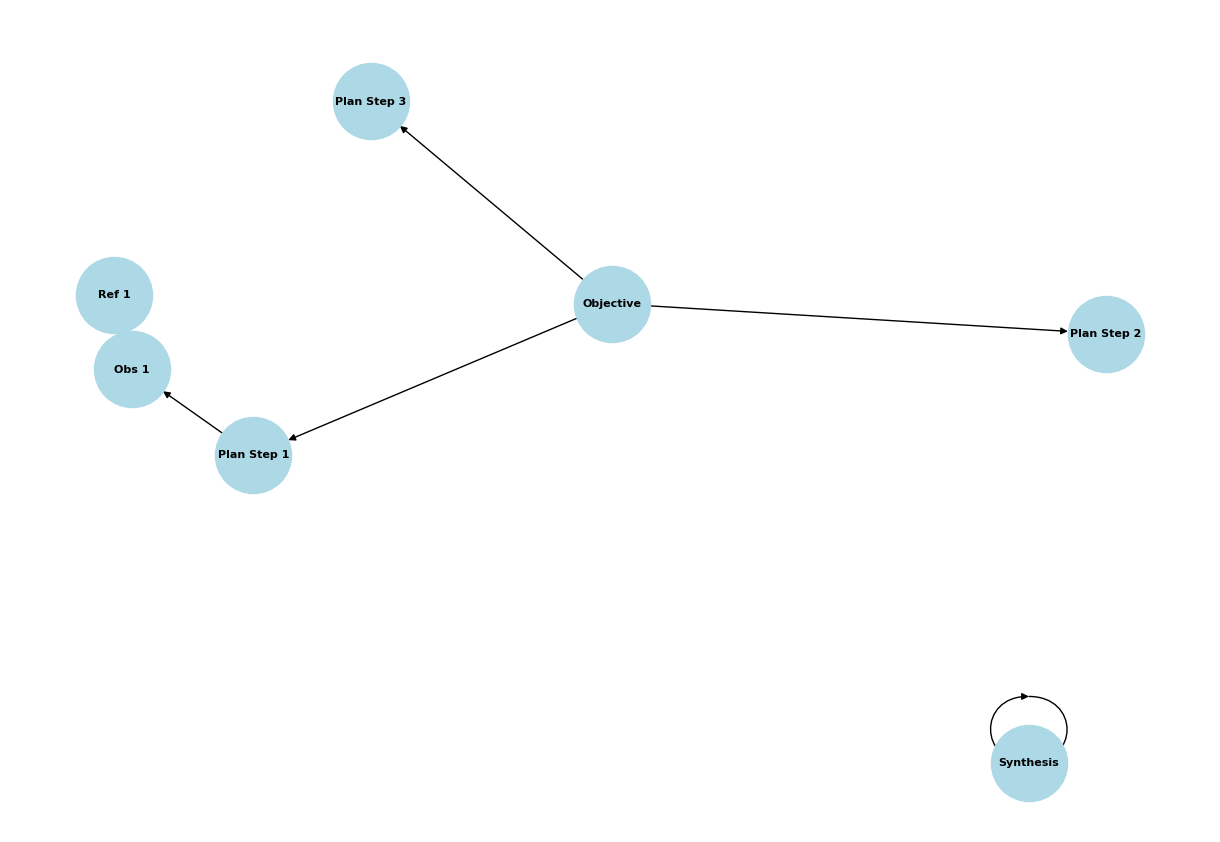

Response: ### Introduction

Chemical rockets rely on the explosive energy released during combustion to propel a spacecraft forward. These engines burn fuel and oxidizer gases, creating shock waves and high temperatures that cause the rocket's payload to accelerate. Chemical rockets typically operate within a limited range due to the inefficiency of their design, which limits their speed and range.

Ion propulsion systems, on the other hand, harness the electric current generated by the sun to propel a spacecraft. Unlike chemical rockets, ion propulsion does not require fuel, making it more efficient and capable of reaching extremely high speeds. However, ion propulsion systems face significant challenges related to energy storage, control, and safety, necessitating advanced technology and maintenance.

### Creative Insights

One innovative approach to improving the efficiency of ion propulsion systems involves using a combination of ion thrusters and ion engine exhaust. By combining t

In [10]:
# =============================================================================
# SECTION 8: SPECIALIZED APPLICATION SYSTEMS
# =============================================================================


def intelligent_assistant(query):
    query_lower = query.lower()

    if any(
        word in query_lower
        for word in ["problem", "issue", "noise", "fault", "troubleshoot"]
    ):
        print("Selected method: Self-RAG (diagnostic query)")
        return self_rag(query)

    elif any(
        word in query_lower
        for word in ["compare", "difference", "versus", "vs", "analysis"]
    ):
        print("Selected method: Dynamic Agent (comparative query)")
        result = dynamic_agent(query)
        return result["response"] if isinstance(result, dict) else result

    else:
        print("Selected method: Simple RAG (general query)")
        response, _ = simple_rag(query)
        return response


def research_agent(topic):
    research_objective = f"Conduct comprehensive research on: {topic}. Include multiple perspectives, technical details, and practical implications."
    return dynamic_agent(research_objective)


# Test specialized systems
test_queries = [
    "My spacecraft is experiencing thrust problems during launch",
    "Compare chemical rockets versus ion propulsion systems",
    "How does orbital mechanics work?",
]

print("Testing Intelligent Assistant:")
print("=" * 40)

for i, query in enumerate(test_queries, 1):
    print(f"\n\nTest {i}: {query}")
    print("-" * 30)
    response = intelligent_assistant(query)
    print(f"Response: {response}")

In [11]:
# =============================================================================
# SECTION 9: SYSTEM VALIDATION AND PERFORMANCE ANALYSIS
# =============================================================================


def comprehensive_system_validation():
    validation_test_cases = [
        {
            "query": "Explain the rocket equation and its significance in space exploration",
            "category": "Scientific/Technical",
            "expected_method": "Simple RAG",
        },
        {
            "query": "Compare the advantages and disadvantages of chemical vs electric propulsion",
            "category": "Comparative Analysis",
            "expected_method": "Dynamic Agent",
        },
        {
            "query": "My rocket engine is showing irregular thrust patterns",
            "category": "Problem Solving",
            "expected_method": "Self-RAG",
        },
        {
            "query": "What are the challenges of interplanetary travel?",
            "category": "General Knowledge",
            "expected_method": "Simple RAG",
        },
        {
            "query": "Analyze the future prospects of Mars colonization technology",
            "category": "Research/Analysis",
            "expected_method": "Dynamic Agent",
        },
    ]

    print("COMPREHENSIVE SYSTEM VALIDATION")
    print("=" * 50)

    results = []

    for i, test_case in enumerate(validation_test_cases, 1):
        print(f"\nTest Case {i}: {test_case['category']}")
        print(f"Query: {test_case['query']}")
        print(f"Expected Method: {test_case['expected_method']}")
        print("-" * 40)

        response = intelligent_assistant(test_case["query"])

        response_length = len(response.split())
        has_technical_content = any(
            term in response.lower()
            for term in ["equation", "physics", "energy", "force", "velocity", "mass"]
        )

        result = {
            "test_case": i,
            "category": test_case["category"],
            "response_length": response_length,
            "has_technical_content": has_technical_content,
            "response_preview": (
                response[:200] + "..." if len(response) > 200 else response
            ),
        }

        results.append(result)

        print(f"Response Length: {response_length} words")
        print(f"Technical Content: {has_technical_content}")
        print(f"Response Preview: {result['response_preview']}")

    avg_response_length = np.mean([r["response_length"] for r in results])
    technical_content_rate = np.mean([r["has_technical_content"] for r in results])

    print("\n" + "=" * 50)
    print("VALIDATION SUMMARY")
    print("=" * 50)
    print(f"Total Test Cases: {len(results)}")
    print(f"Average Response Length: {avg_response_length:.1f} words")
    print(f"Technical Content Rate: {technical_content_rate:.1%}")
    print(
        f"System Successfully Processed: {len(results)}/{len(validation_test_cases)} queries"
    )

    return {
        "results": results,
        "metrics": {
            "avg_response_length": avg_response_length,
            "technical_content_rate": technical_content_rate,
            "success_rate": len(results) / len(validation_test_cases),
        },
    }

AGENTIC AI FLEXIBILITY TESTS

TEST 1: Investigate rocket propulsion: Brainstorm basics, calculate sample delta-v using rocket equation creatively, analyze implications for Mars missions with innovative angles.
----------------------------------------
AGENT OBJECTIVE: Investigate rocket propulsion: Brainstorm basics, calculate sample delta-v using rocket equation creatively, analyze implications for Mars missions with innovative angles.
Generated Plan: [
  {
    "step": 1,
    "tool": "search_documents",
    "params": {
      "query": "rocket propulsion"
    },
    "outcome": "Retrieve comprehensive information on rocket propulsion.",
    "rationale": "This step involves searching for detailed explanations of various rocket propulsion methods to understand their principles and applications."
  },
  {
    "step": 2,
    "tool": "analyze",
    "params": {
      "text": "Rocket propulsion is a crucial technology in space exploration."
    },
    "outcome": "Identify key concepts and their 

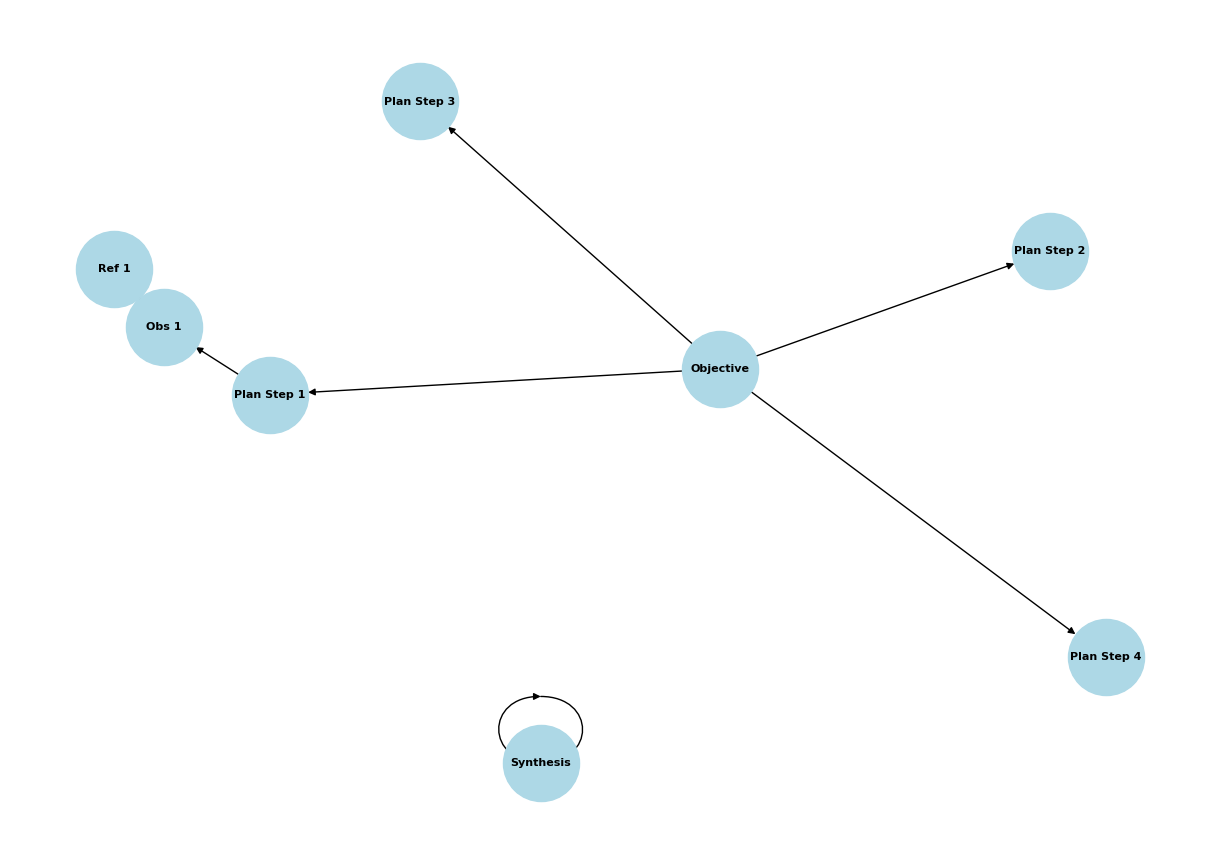

Validation: Steps=1 | Thoughts=True | Reflections=True | Creative=True | PASS=False

TEST 2: Research STS-55 mission: Retrieve facts creatively, compare with STS-128 using diverse perspectives, synthesize differences without fabrication, propose hypothetical extensions.
----------------------------------------
AGENT OBJECTIVE: Research STS-55 mission: Retrieve facts creatively, compare with STS-128 using diverse perspectives, synthesize differences without fabrication, propose hypothetical extensions.
Generated Plan: [
  {
    "step": 1,
    "tool": "search_documents",
    "params": {
      "query": "STS-55 mission facts",
      "k": 5
    },
    "outcome": "Retrieve facts about the STS-55 mission from the knowledge base.",
    "rationale": "This step allows us to gather comprehensive information about the mission, which is crucial for understanding its details."
  },
  {
    "step": 2,
    "tool": "analyze",
    "params": {
      "text": "STS-55 mission"
    },
    "outcome": "Analyze

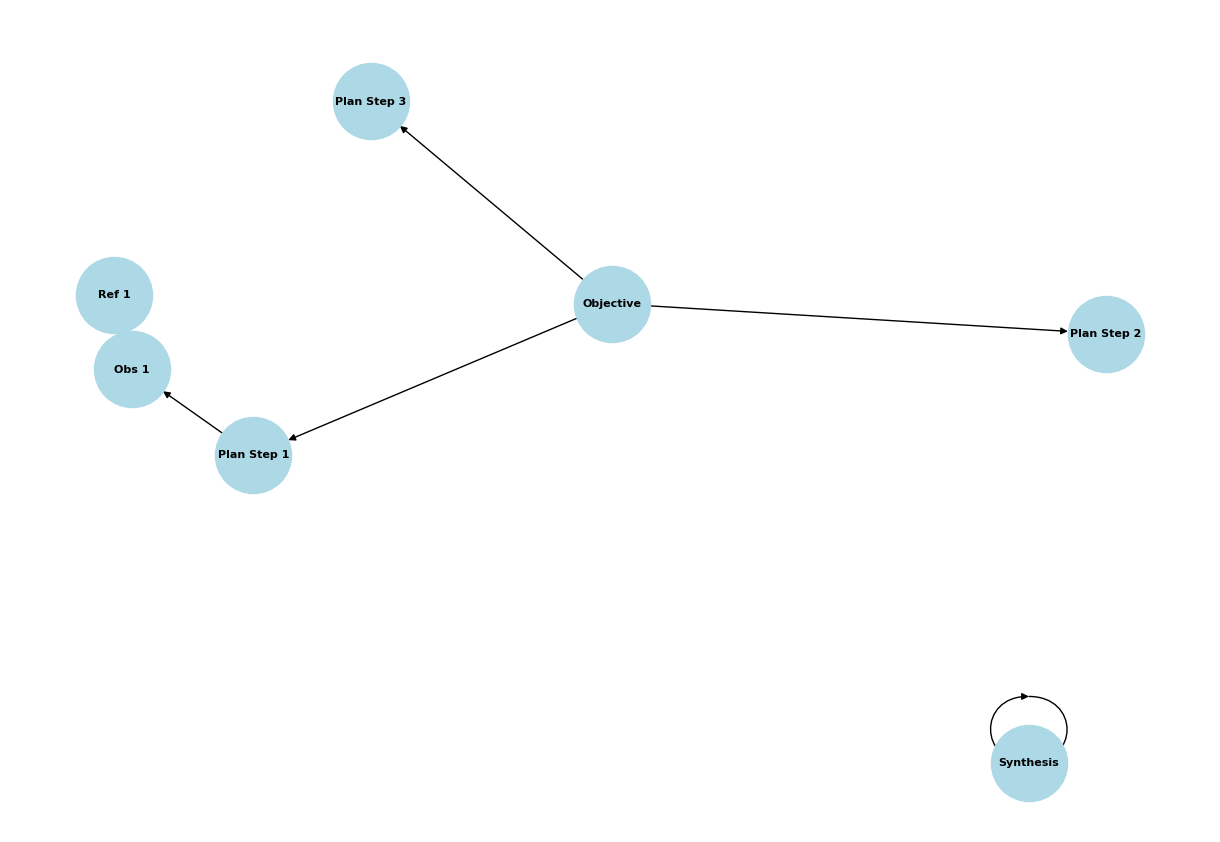

Validation: Steps=1 | Thoughts=True | Reflections=True | Creative=True | PASS=False

TEST 3: Explore NASA principles: Gather info dynamically, generate a hypothetical application to modern exploration with creative twists, reflect on feasibility and evolve ideas.
----------------------------------------
AGENT OBJECTIVE: Explore NASA principles: Gather info dynamically, generate a hypothetical application to modern exploration with creative twists, reflect on feasibility and evolve ideas.
Generated Plan: [
  {
    "step": 1,
    "tool": "search_documents",
    "params": {
      "query": "Explore NASA principles: Gather info dynamically, generate a hypothetical application to modern exploration with creative twists, reflect on feasibility and evolve ideas."
    },
    "outcome": "Initial search",
    "rationale": "Foundation gathering"
  },
  {
    "step": 2,
    "tool": "analyze",
    "params": {
      "text": "results"
    },
    "outcome": "Deep dive",
    "rationale": "Build insights

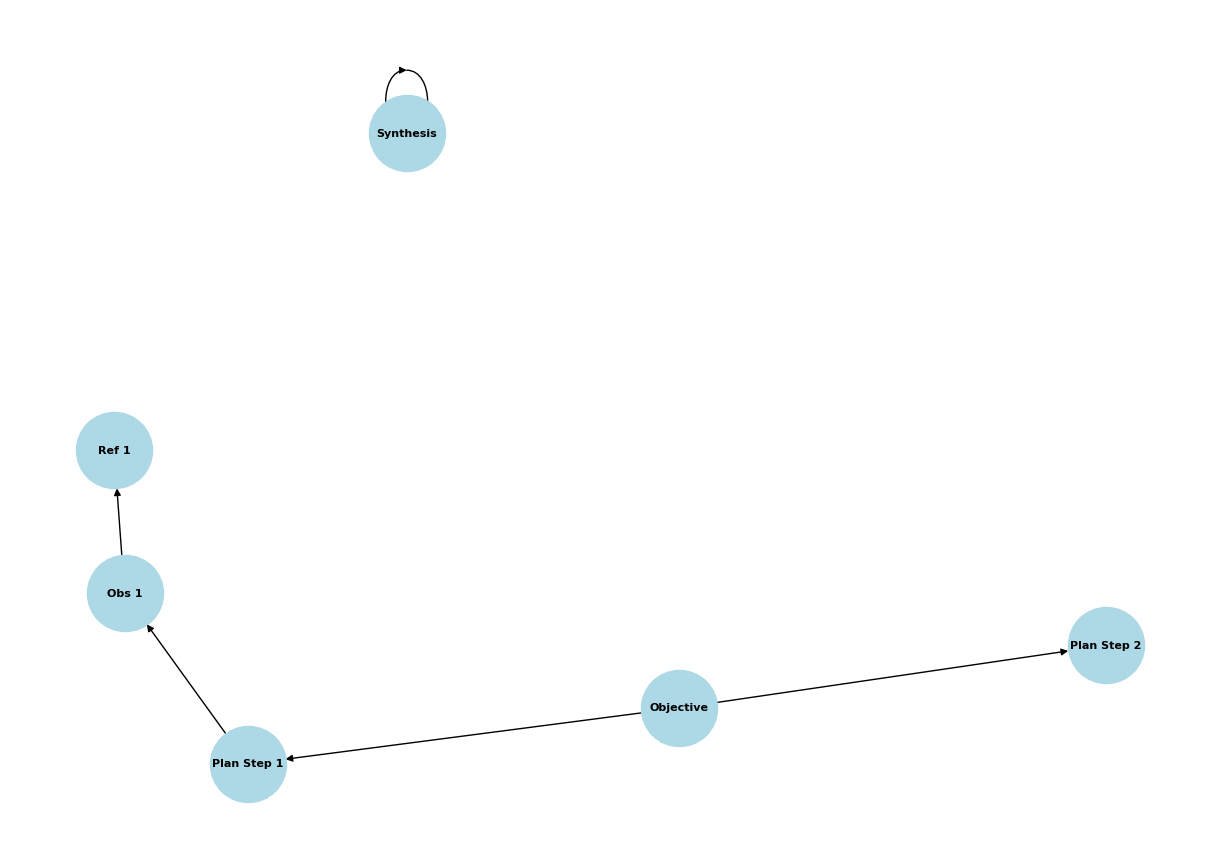

Validation: Steps=1 | Thoughts=True | Reflections=True | Creative=True | PASS=False

AGENT FLEXIBILITY TEST SUMMARY
 Test ID  Steps Executed                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    Plan Preview Validation
       1               1 [\n  {\n    "step": 1,\n    "tool": "search_documents",\n    "params": 

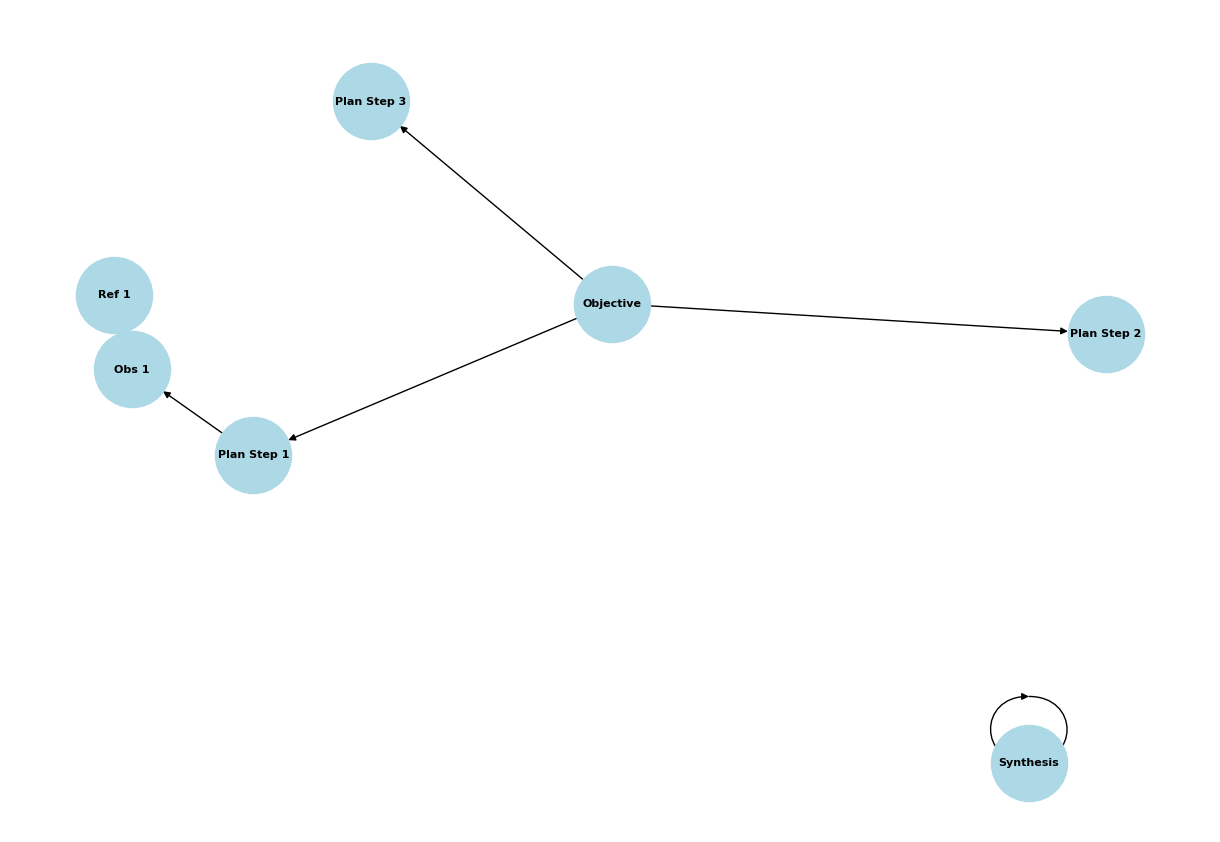

Response Length: 375 words
Technical Content: True
Response Preview: Chemical propulsion systems have been a cornerstone of human spaceflight since the dawn of aviation. They offer a reliable method of achieving long-duration travel at high speeds, but they come with s...

Test Case 3: Problem Solving
Query: My rocket engine is showing irregular thrust patterns
Expected Method: Self-RAG
----------------------------------------
Selected method: Simple RAG (general query)
Response Length: 121 words
Technical Content: True
Response Preview: Your statement "My rocket engine is showing irregular thrust patterns" aligns with the information provided. According to the passage, your rocket engine generates thrust based on the mass of the gase...

Test Case 4: General Knowledge
Query: What are the challenges of interplanetary travel?
Expected Method: Simple RAG
----------------------------------------
Selected method: Simple RAG (general query)
Response Length: 217 words
Technical Content: Fals

In [12]:
# =============================================================================
# SECTION 10: AGENTIC AI FLEXIBILITY TESTS
# =============================================================================

"""
Step-by-Step Test Cases for Agentic AI Capabilities:

These tests validate the agent's ability to:
1. Plan dynamically using LLM-generated steps with creativity.
2. Reason through thoughts, observations, and reflections.
3. Act via tools in a flexible manner (open-ended 'think' tool for pure reasoning).
4. Observe and adapt (revise plans based on context and rationale).
5. Terminate appropriately with innovative synthesis.

Each test includes:
- Objective: Complex query requiring multi-step reasoning.
- Expected Behaviors: Creative planning (3-8 steps with rationales), Execution (diverse tools), Reflection (adaptive insights), Flexibility (dynamic revisions).
- Validation: Check steps, thoughts/reflections presence, response creativity (length + keywords).

Run each test and inspect outputs for:
- Dynamic plan generation (JSON-structured, rationale-driven).
- Step-by-step reasoning (thoughts, actions, observations).
- Flexibility: Observe revisions and 'think' steps for creativity.
- Graph: Auto-generated visualization of process.
"""

agent_flex_tests = [
    {
        "objective": "Investigate rocket propulsion: Brainstorm basics, calculate sample delta-v using rocket equation creatively, analyze implications for Mars missions with innovative angles.",
        "expected_steps": 5,  # Planning, search/think, calculate, analyze, synthesize
        "validation_criteria": "Plan includes 'think' or creative tools; reflections suggest adaptations; response covers innovative calculation and future ideas.",
    },
    {
        "objective": "Research STS-55 mission: Retrieve facts creatively, compare with STS-128 using diverse perspectives, synthesize differences without fabrication, propose hypothetical extensions.",
        "expected_steps": 6,  # Planning, searches, generate/compare, reflect
        "validation_criteria": "Dynamic plan with rationales; observations cite docs; flexibility via revisions; coherent, creative comparison with hypotheses.",
    },
    {
        "objective": "Explore NASA principles: Gather info dynamically, generate a hypothetical application to modern exploration with creative twists, reflect on feasibility and evolve ideas.",
        "expected_steps": 4,  # Shorter for creativity test
        "validation_criteria": "Plan adapts with 'generate' and 'think'; observations from search; termination after insightful reflections; response structured with innovative hypothesis.",
    },
]

print("AGENTIC AI FLEXIBILITY TESTS")
print("=" * 50)

agent_results = []
for i, test in enumerate(agent_flex_tests, 1):
    print(f"\nTEST {i}: {test['objective']}")
    print("-" * 40)
    result = dynamic_agent(test["objective"])

    # Validation
    steps_exec = result["steps_executed"]
    has_thoughts = len(result["thoughts"]) > 0
    has_reflections = len(result["reflections"]) > 0
    response_creativity = len(result["response"].split()) > 80 and any(
        term in result["response"].lower()
        for term in ["innovative", "creative", "hypothetical", "perspective"]
    )

    validation_pass = (
        steps_exec >= test["expected_steps"] - 1
        and has_thoughts
        and has_reflections
        and response_creativity
    )

    print(
        f"Validation: Steps={steps_exec} | Thoughts={has_thoughts} | Reflections={has_reflections} | Creative={response_creativity} | PASS={validation_pass}"
    )

    agent_results.append(
        {
            "test": i,
            "steps": steps_exec,
            "plan_preview": json.dumps(result["plan"][:2], indent=2),  # First 2 steps
            "final_response_preview": result["response"][:150] + "...",
            "pass": validation_pass,
        }
    )

# Summary Table for Agent Tests
print("\n" + "=" * 50)
print("AGENT FLEXIBILITY TEST SUMMARY")
print("=" * 50)
summary_data = []
for res in agent_results:
    summary_data.append(
        [
            res["test"],
            res["steps"],
            res["plan_preview"],
            "PASS" if res["pass"] else "FAIL",
        ]
    )

import pandas as pd

df = pd.DataFrame(
    summary_data, columns=["Test ID", "Steps Executed", "Plan Preview", "Validation"]
)
print(df.to_string(index=False))

# Overall Agent Success Rate
success_rate = sum(1 for r in agent_results if r["pass"]) / len(agent_results)
print(f"\nAgent Flexibility Success Rate: {success_rate:.1%}")

# Run comprehensive validation
validation_results = comprehensive_system_validation()

____

References

In [13]:
print(
    """
ACADEMIC REFERENCES AND CITATIONS

This educational implementation builds upon foundational research in 
information retrieval, natural language processing, and AI systems:

1. Retrieval-Augmented Generation:
   Lewis, P., et al. (2020). "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks." 
   arXiv:2005.11401. https://arxiv.org/abs/2005.11401

2. Dense Passage Retrieval:
   Karpukhin, V., et al. (2020). "Dense Passage Retrieval for Open-Domain Question Answering."
   arXiv:2004.04906. https://arxiv.org/abs/2004.04906

3. Self-RAG:
   Asai, A., et al. (2023). "Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection."
   arXiv:2310.11511. https://arxiv.org/abs/2310.11511

4. HyDE (Hypothetical Document Embeddings):
   Gao, L., et al. (2022). "Precise Zero-Shot Dense Retrieval without Relevance Labels."
   arXiv:2212.10496. https://arxiv.org/abs/2212.10496

5. BM25 Algorithm:
   Robertson, S., & Zaragoza, H. (2009). "The Probabilistic Relevance Framework: BM25 and Beyond."
   Foundations and Trends in Information Retrieval, 3(4), 333-389.

6. Sentence Transformers:
   Reimers, N., & Gurevych, I. (2019). "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks."
   arXiv:1908.10084. https://arxiv.org/abs/1908.10084

7. FAISS (Facebook AI Similarity Search):
   Johnson, J., Douze, M., & Jégou, H. (2019). "Billion-scale similarity search with GPUs."
   IEEE Transactions on Big Data, 7(3), 535-547.

8. ReAct: Synergizing Reasoning and Acting in Language Models:
   Yao, S., et al. (2022). arXiv:2210.03629.

9. Reflexion: Language Agents with Verbal Reinforcement Learning:
   Shinn, N., et al. (2023). arXiv:2303.11366.

10. Tree of Thoughts: Deliberate Problem Solving with Large Language Models:
    Yao, S., et al. (2023). arXiv:2305.10601.

TECHNICAL LIBRARIES AND FRAMEWORKS:

- HuggingFace Transformers: https://huggingface.co/docs/transformers/
- Sentence Transformers: https://www.sbert.net/
- LangChain: https://python.langchain.com/
- FAISS: https://faiss.ai/
- PyTorch: https://pytorch.org/
- NumPy: https://numpy.org/
- NetworkX: https://networkx.org/

DATA SOURCES:

This educational implementation uses publicly available NASA educational materials
as demonstration data, in accordance with NASA's open data policies and
educational mission. All NASA content is used for educational purposes only.

NASA Open Data Policy: https://www.nasa.gov/open/
NASA Educational Resources: https://www.nasa.gov/audience/foreducators/

DISCLAIMER:

This implementation is developed solely for educational and research purposes.
It is not intended for commercial use, production deployment, or any application
requiring guaranteed performance or reliability. The code serves as a learning
resource for understanding modern AI techniques in information retrieval and
text generation.

Users should refer to original research papers and official documentation
for production implementations and cite appropriate sources when using
these techniques in academic or commercial contexts.
"""
)


ACADEMIC REFERENCES AND CITATIONS

This educational implementation builds upon foundational research in 
information retrieval, natural language processing, and AI systems:

1. Retrieval-Augmented Generation:
   Lewis, P., et al. (2020). "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks." 
   arXiv:2005.11401. https://arxiv.org/abs/2005.11401

2. Dense Passage Retrieval:
   Karpukhin, V., et al. (2020). "Dense Passage Retrieval for Open-Domain Question Answering."
   arXiv:2004.04906. https://arxiv.org/abs/2004.04906

3. Self-RAG:
   Asai, A., et al. (2023). "Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection."
   arXiv:2310.11511. https://arxiv.org/abs/2310.11511

4. HyDE (Hypothetical Document Embeddings):
   Gao, L., et al. (2022). "Precise Zero-Shot Dense Retrieval without Relevance Labels."
   arXiv:2212.10496. https://arxiv.org/abs/2212.10496

5. BM25 Algorithm:
   Robertson, S., & Zaragoza, H. (2009). "The Probabilistic Relevance Fram